<a href="https://colab.research.google.com/github/bbfss/StudyNotes/blob/main/%E6%BA%90%E7%A0%81%E5%AE%9E%E7%8E%B0/Bert%E5%A4%8D%E7%8E%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

参考文档:


1.   [代码复现](https://neptune.ai/blog/how-to-code-bert-using-pytorch-tutorial)
2.   [原理说明](https://x-hao.github.io/2021/07/21/bert/)



Bert的网络架构, 选了Transformer的Encoder部分

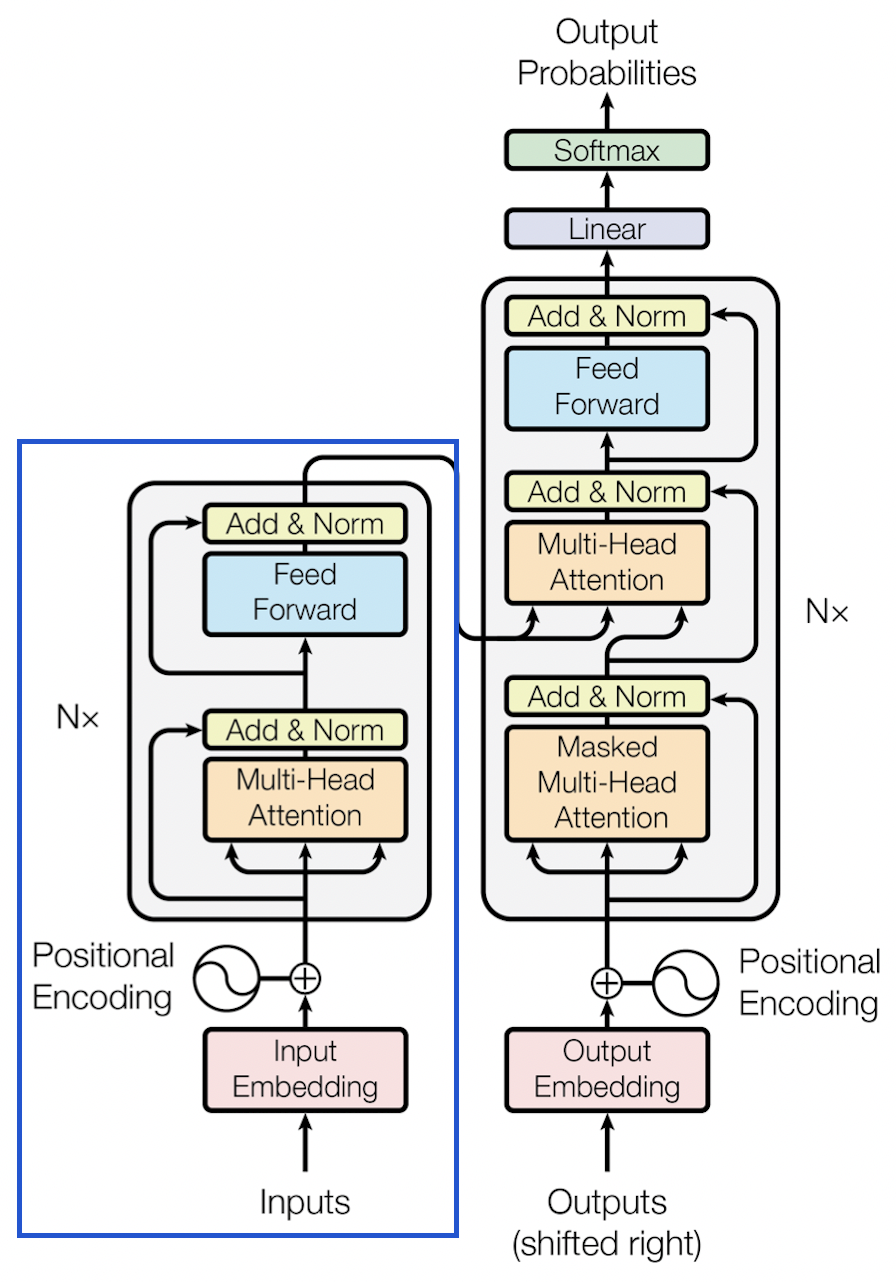

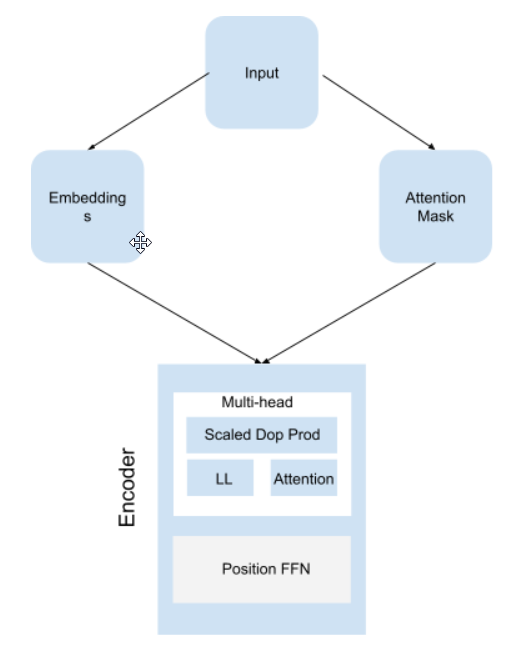

Bert要实现两个任务

- 任务一: Masked LM (带mask的语言模型训练)
  - 关于传统的语言模型训练, 都是采用left-to-right, 或者left-to-right + right-to-left结合的方式, 但这种单向方式或者拼接的方式提取特征的能力有限. 为此BERT提出一个深度双向表达模型(deep bidirectional representation). 即采用MASK任务来训练模型.
  - 1: 在原始训练文本中, 随机的抽取15%的token作为参与MASK任务的对象.
  - 2: 在这些被选中的token中, 数据生成器并不是把它们全部变成[MASK], 而是有下列3种情况.
    - 2.1: 在80%的概率下, 用[MASK]标记替换该token, 比如my dog is hairy -> my dog is [MASK]
    - 2.2: 在10%的概率下, 用一个随机的单词替换token, 比如my dog is hairy -> my dog is apple
    - 2.3: 在10%的概率下, 保持该token不变, 比如my dog is hairy -> my dog is hairy
  - 3: 模型在训练的过程中, 并不知道它将要预测哪些单词? 哪些单词是原始的样子? 哪些单词被遮掩成了[MASK]? 哪些单词被替换成了其他单词? 正是在这样一种高度不确定的情况下, 反倒逼着模型快速学习该token的分布式上下文的语义, 尽最大努力学习原始语言说话的样子. 同时因为原始文本中只有15%的token参与了MASK操作, 并不会破坏原语言的表达能力和语言规则.
- 任务二: Next Sentence Prediction (下一句话预测任务)
  - 在NLP中有一类重要的问题比如QA(Quention-Answer), NLI(Natural Language Inference), 需要模型能够很好的理解两个句子之间的关系, 从而需要在模型的训练中引入对应的任务. 在BERT中引入的就是Next Sentence Prediction任务. 采用的方式是输入句子对(A, B), 模型来预测句子B是不是句子A的真实的下一句话.
  - 1: 所有参与任务训练的语句都被选中作为句子A.
    - 1.1: 其中50%的B是原始文本中真实跟随A的下一句话. (标记为IsNext, 代表正样本)
    - 1.2: 其中50%的B是原始文本中随机抽取的一句话. (标记为NotNext, 代表负样本)
  - 2: 在任务二中, BERT模型可以在测试集上取得97%-98%的准确率

整个程序分为 4 个部分：

1. Preprocessing  预处理
2. Building model  构建模型
3. Loss and Optimization  损失和优化
4. Training  训练

In [27]:
import re
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import torch.optim as optim
import copy
from torch.utils.data import Dataset,DataLoader

In [28]:
maxlen = 30
batch_size = 6
max_pred = 5 # max tokens of prediction
n_layers = 6
n_heads = 12
d_model = 768
d_ff = 768*4 # 4*d_model, FeedForward dimension
d_k = d_v = 64  # dimension of K(=Q), V
n_segments = 2

# 数据预处理

In [29]:
# 这是一段两个人的对话
text = (
    'Hello, how are you? I am Romeo.\n' # R
    'Hello, Romeo My name is Juliet. Nice to meet you.\n' # J
    'Nice meet you too. How are you today?\n' # R
    'Great. My baseball team won the competition.\n' # J
    'Oh Congratulations, Juliet\n' # R
    'Thank you Romeo\n' # J
    'Where are you going today?\n' # R
    'I am going shopping. What about you?\n' # J
    'I am going to visit my grandmother. she is not very well' # R
   )

In [30]:
sentences = re.sub("[.,!?\\-]", '', text.lower()).split('\n')  # 将标点符号全部去掉, 文本当中末尾的n是换行的意思, 然后就用换行符号切割成多个句子列表
sentences

['hello how are you i am romeo',
 'hello romeo my name is juliet nice to meet you',
 'nice meet you too how are you today',
 'great my baseball team won the competition',
 'oh congratulations juliet',
 'thank you romeo',
 'where are you going today',
 'i am going shopping what about you',
 'i am going to visit my grandmother she is not very well']

In [31]:
# 从句子中构造词汇表
word_list = list(set(" ".join(sentences).split())) # 用空格拼接sentences的元素, 然后split()再用空格分割他们, 得到多个单词, 再转化成set去重, 最后转化回列表
word_list

['today',
 'too',
 'i',
 'hello',
 'where',
 'how',
 'am',
 'romeo',
 'is',
 'competition',
 'very',
 'visit',
 'great',
 'you',
 'grandmother',
 'well',
 'about',
 'she',
 'going',
 'juliet',
 'what',
 'name',
 'are',
 'to',
 'my',
 'baseball',
 'thank',
 'shopping',
 'not',
 'team',
 'meet',
 'nice',
 'the',
 'congratulations',
 'won',
 'oh']

以下是Bert在训练期间会使用到的特殊符号



| Token  | Purpose (用途) |
|--------|----------------|
| [CLS]  | The first token is always classification<br>第一个标记始终是分类 |
| [SEP]  | Separates two sentences<br>分隔两个句子 |
| [END]  | End the sentence.<br>结束句子 |
| [PAD]  | Use to truncate the sentence with equal length.<br>用于截断句子以保持等长 |
| [MASK] | Use to create a mask by replacing the original word.<br>用于通过替换原始词来创建一个掩码 |


In [32]:
# 创建word_dic number_dic 词汇字典, 然后vobal_size是词表的长度

word_dict = {'[PAD]':0, '[CLS]':1, '[SEP]':2, '[MASK]':3} # 将特殊符号编入字典

# 将前面的词汇表编入到词汇字典当中, key是word, value是index
for i, w in enumerate(word_list):
  word_dict[w] = i + 4

# 再创建数字字典, key是index, value是word
number_dict = {index:word for word, index in word_dict.items()}

vobal_size = len(word_dict)

print(word_dict.items())
print(number_dict.items())

dict_items([('[PAD]', 0), ('[CLS]', 1), ('[SEP]', 2), ('[MASK]', 3), ('today', 4), ('too', 5), ('i', 6), ('hello', 7), ('where', 8), ('how', 9), ('am', 10), ('romeo', 11), ('is', 12), ('competition', 13), ('very', 14), ('visit', 15), ('great', 16), ('you', 17), ('grandmother', 18), ('well', 19), ('about', 20), ('she', 21), ('going', 22), ('juliet', 23), ('what', 24), ('name', 25), ('are', 26), ('to', 27), ('my', 28), ('baseball', 29), ('thank', 30), ('shopping', 31), ('not', 32), ('team', 33), ('meet', 34), ('nice', 35), ('the', 36), ('congratulations', 37), ('won', 38), ('oh', 39)])
dict_items([(0, '[PAD]'), (1, '[CLS]'), (2, '[SEP]'), (3, '[MASK]'), (4, 'today'), (5, 'too'), (6, 'i'), (7, 'hello'), (8, 'where'), (9, 'how'), (10, 'am'), (11, 'romeo'), (12, 'is'), (13, 'competition'), (14, 'very'), (15, 'visit'), (16, 'great'), (17, 'you'), (18, 'grandmother'), (19, 'well'), (20, 'about'), (21, 'she'), (22, 'going'), (23, 'juliet'), (24, 'what'), (25, 'name'), (26, 'are'), (27, 'to'), 

### MyDataSet类 : MASK 和 Embeddings

在丢入到网络之前, 需要对输入序列进行格式化, 总共四种种操作 : token embedding, segment embedding, and position embedding. Mask

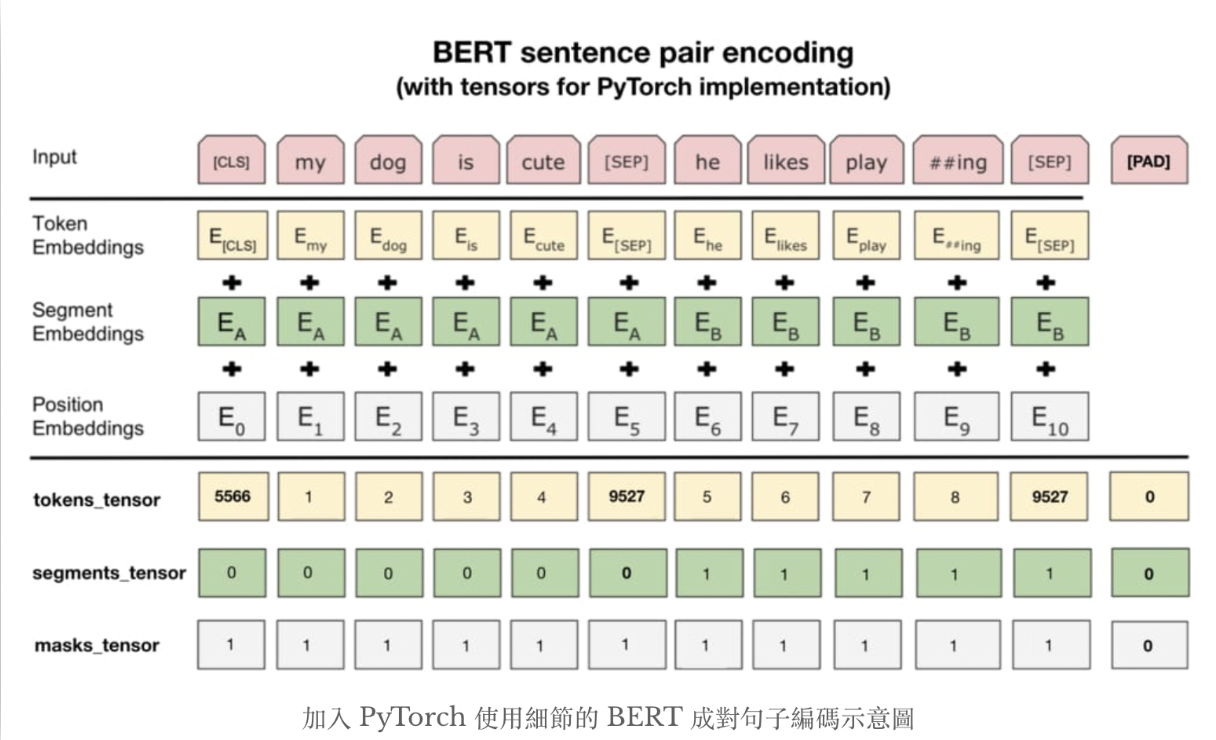

在实际运用中最重要的是第二条分割线下面的操作，需要将原始文本转换成3种id tensor 和 一种mask tensor：

1. tensor_tokens：每个token对应的索引值。(注意图片来自blog, 本文中pad 为 0, cls为1, sep为2, mask为3)
2. tensor_segments ：用来识别句子界限，第一句为0，第二句为1，句子间的[SEP]为0。
3. tensor_positions : 为序列中每个嵌入提供位置信息, Bert的位置信息不是Transformer一样的三角函数, 而是通过神经网络学习
4. Masks_tensor：用来界定自注意力机制范围。1让BERT关注该位置，0则代表padding不需要关注

创建一个训练时候使用的batch类, 主要是存储原始数据和mask

In [33]:
class MyDataSet(Dataset):
  """
  存储训练时候使用的数据:
  1. tensor_tokens 将两个句子拼接在一起, 转化成的向量
  2. tensor_masked_pos 被遮掩的token的位置的列表
  3. tensor_masked_token 被遮蔽的token的列表
  3. tensor_segments 区分两个句子的分界线
  4. tensor_positions 根据序列构建出来的记录每个token的位置序列
  4. tensor_bool_next 代表正负样本, 如果两句话是相邻的就是正样本, 不相邻就是负样本
  5. tensor_pad_attention_mask 该mask是用于注意力机制的, 当tensor_tokens作为key的时候, 其对应的mask, 其中False代表不要mask, True代表要mask


  输入:
  1. word_dict : <词, index>
  2. number_dict : <index, 词>
  3. sentences : 包含句子的列表 (为NSP使用)

  输出:
  return (tensor_tokens, tensor_segments, tensor_masked_pos, tensor_masked_token, tensor_positions, tensor_bool_next)作为一个元素的batch_data列表



  其他超参数
  1. max_pred 一句话允许被mask的最大数量
  2. batch_size 一个batch里面的尺寸
  3. max_len 序列的最大长度 (不足就扩充到这个长度)
  """
  def __init__(self, word_dict, number_dict, sentences):
    # 用于存储生成出来的数据, 每一个元素都是一个样本, (tensor_tokens, tensor_segments, tensor_masked_pos, tensor_masked_token, tensor_positions, tensor_bool_next)
    self.batch_data = []
    self.tensor_tokens = []
    self.tensor_segments = []
    self.tensor_masked_pos = []
    self.tensor_masked_token = []
    self.tensor_positions = []
    self.tensor_bool_next = []
    self.tensor_pad_attention_mask = []

    # 一个batch的正负样本计数
    positive = negative = 0

    # 每个batch的正负样本都占一半
    while positive != batch_size/2 or negative != batch_size/2:

      # index_sentence_a/b 随机选了sentences句子集当中的一句话, 取了他的下标
      index_sentence_a, index_sentence_b = random.randrange(len(sentences)), random.randrange(len(sentences))
      sentence_a = sentences[index_sentence_a]
      sentence_b = sentences[index_sentence_b]

      #### 1. tensor_tokens : 两句话拼接后的输入tensor
      list_sentence_a = [word_dict[word] for word in sentence_a.split()]
      list_sentence_b = [word_dict[word] for word in sentence_b.split()]
      tensor_tokens = [word_dict['[CLS]']] + list_sentence_a + [word_dict['[SEP]']] + list_sentence_b + [word_dict['[SEP]']]
      #### 2. tensor_segments, 用于区分这两句话的间隔
      tensor_segments = [0] * (1 + len(list_sentence_a) + 1) + [1] * (len(list_sentence_b) + 1)

      #### 3. tensor_positions, 为token 添加位置信息
      tensor_positions = [i for i in range(max_len)] # 序列的最大长度, 构造序列

      #### 4. list_maske_pos/token, 用于任务一
      # num_mask 代表当前这个句子要mask多少个元素, 0.15代表mask15%的元素
      num_mask = min(max_pred, max(1, int(len(tensor_tokens) * 0.15)))

      # 挑选出可以mask的位置, 放入到list_masked_pos/token
      positional_masked_pos = [i for i,token in enumerate(tensor_tokens)
                    if token != word_dict['[CLS]'] and token != word_dict['[SEP]']]
      random.shuffle(positional_masked_pos)
      list_masked_pos = []
      list_masked_token = []
      for masked_pos in positional_masked_pos[:num_mask]:
        list_masked_token.append(tensor_tokens[masked_pos]) # Convert tensor to scalar
        list_masked_pos.append(masked_pos)
        # 对于被masked的元素中, 80%mask, 10%替换成其他字符, 10%保持不变
        if random.random() < 0.8 :
          tensor_tokens[masked_pos] = word_dict['[MASK]']
        elif random.random() < 0.5:
          tensor_tokens[masked_pos] = random.randint(4, vobal_size-1) # 前面四个是特殊字符, 替换的是普通词表

      # 把tensor_tokens 填充padding 直到maxlen
      num_pad = max_len - len(tensor_tokens)
      tensor_tokens.extend([word_dict['[PAD]']] * num_pad)
      # masked_pos.extend([0] * num_pad) # masked_pos is not a list of tensors
      tensor_segments.extend([0] * num_pad)

      # 把list_masked_pos 和 token 扩充到固定长度
      if max_pred > num_mask :
        num_pad = max_pred - num_mask
        list_masked_pos.extend([0] * num_pad)
        list_masked_token.extend([word_dict['[PAD]']] * num_pad)


      if index_sentence_a + 1 == index_sentence_b and positive < batch_size / 2 :
        positive += 1
        self.batch_data.append((tensor_tokens, tensor_segments,list_masked_pos, list_masked_token, tensor_positions, 1))
      elif index_sentence_a + 1 != index_sentence_b and negative < batch_size / 2 :
        negative += 1
        self.batch_data.append((tensor_tokens, tensor_segments, list_masked_pos, list_masked_token, tensor_positions, 0))
    self.batch_data_stack()
    # 5. 制作pad_attention_mask, 这里用于注意力机制当中使用, 其大小为[batch_size, 1, len_key], 因为使用时候注意力机制主要是对每个query对所有key计算注意力分数, 因此这里拓展一个1, 用于到时候的广播运算
    self.tensor_pad_attention_mask = self.get_pad_attention_mask()

  def batch_data_stack(self):
    "将batch_data里面的元素每一类都堆叠起来, 方便后面丢入到神经网络里面并行计算"

    names = ['tokens', 'segments', 'masked_pos', 'masked_token', 'positions', 'bool_next']

    for name, data in zip(names, zip(*self.batch_data)):
        setattr(self, f'tensor_{name}', torch.LongTensor(data))

  def get_pad_attention_mask(self):
    "对于tensor_tokens中是Pad出来的就是True, 非Pad出来的就是False"
    return (self.tensor_tokens == word_dict['[PAD]']).unsqueeze(1)

  def __len__(self):
    # 数据集长度通常按主输入张量长度来算
    return len(self.tensor_tokens)

  def __getitem__(self, index):
    # 返回单个样本，每个张量对应 index 的切片
    return (
        self.tensor_tokens[index],
        self.tensor_segments[index],
        self.tensor_masked_pos[index],
        self.tensor_masked_token[index],
        self.tensor_positions[index],
        self.tensor_bool_next[index],
        self.tensor_pad_attention_mask[index]
    )

## 创建一个Dataset类试一试

In [34]:
max_pred = 5
batch_size = 4
max_len = 30
dataset = MyDataSet(word_dict=word_dict, number_dict=number_dict, sentences=sentences)
# 打印看下数据
print(dataset.batch_data[0])
print(dataset.tensor_pad_attention_mask[0])


print("\nsentence: \n", "\n".join(sentences) , "\n")

# 打印下被mask后的文本
for i, sample in enumerate(dataset.tensor_tokens):
    tokens_text = [number_dict[t.item()] for t in sample if number_dict[t.item()] != '[PAD]']
    print(f"Sample {i}: {tokens_text}")

print("\n tensor_masked_token")
for row in dataset.tensor_masked_token:
    tokens = [number_dict[int(x)] for x in row ]
    print(tokens)



# 确认下被mask记录的位置
print("\n tensor_masked_pos \n", dataset.tensor_masked_pos)


([1, 16, 28, 29, 33, 38, 36, 23, 2, 30, 17, 11, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [7, 0, 0, 0, 0], [13, 0, 0, 0, 0], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], 0)
tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True]])

sentence: 
 hello how are you i am romeo
hello romeo my name is juliet nice to meet you
nice meet you too how are you today
great my baseball team won the competition
oh congratulations juliet
thank you romeo
where are you going today
i am going shopping what about you
i am going to visit my grandmother she is not very well 

Sample 0: ['[CLS]', 'great', 'my', 'baseball', 'team', 'won', 'the', 'juliet', '[SEP]',

In [35]:
dataset = MyDataSet(word_dict=word_dict, number_dict=number_dict, sentences=sentences)
data_loader = DataLoader(dataset,batch_size,True)

## Batch类

In [36]:
class Batch():
    def __init__(self, tokens, segments, masked_pos, masked_token, positions, bool_next, pad_attention_mask):
        """
        tokens, segments, masked_pos, masked_token, positions, bool_next, pad_attention_mask
        都是 batch_size 的张量
        用于接收每次从dataloader返回的数据
        """
        self.tensor_tokens = tokens
        self.tensor_segments = segments
        self.tensor_masked_pos = masked_pos
        self.tensor_masked_token = masked_token
        self.tensor_positions = positions
        self.tensor_bool_next = bool_next
        self.tensor_pad_attention_mask = pad_attention_mask


## 创建一个Batch类试一试

In [37]:
data_iter = iter(data_loader)
# 获取第一次 batch
first_batch = next(data_iter)
batch_data = Batch(*(first_batch))

# 网络架构

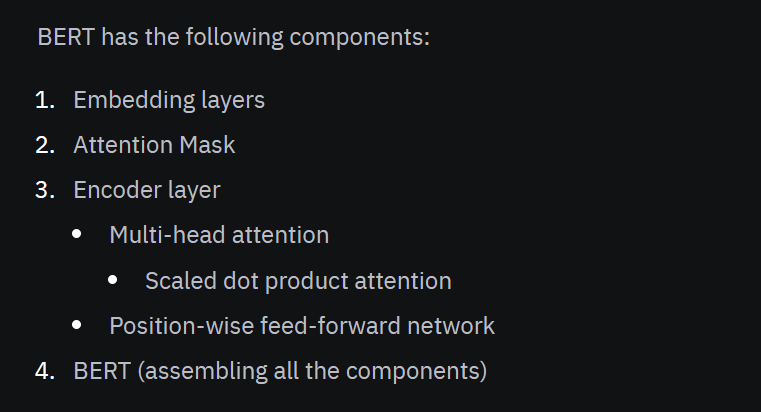

## Embedding层

前面Batch类已经构造了三个Embedding层输入, 分别是
1. Positions 位置输入 (总共有max_len种)
2. segments 分割两个句子(总共有0 和 1 两种)
3. tokens 本身自己的输入 (总共有vobal_size种)

接下来根据这三种输入, 构建三个对应的Embedding层, 将输入信号转化成词嵌入向量



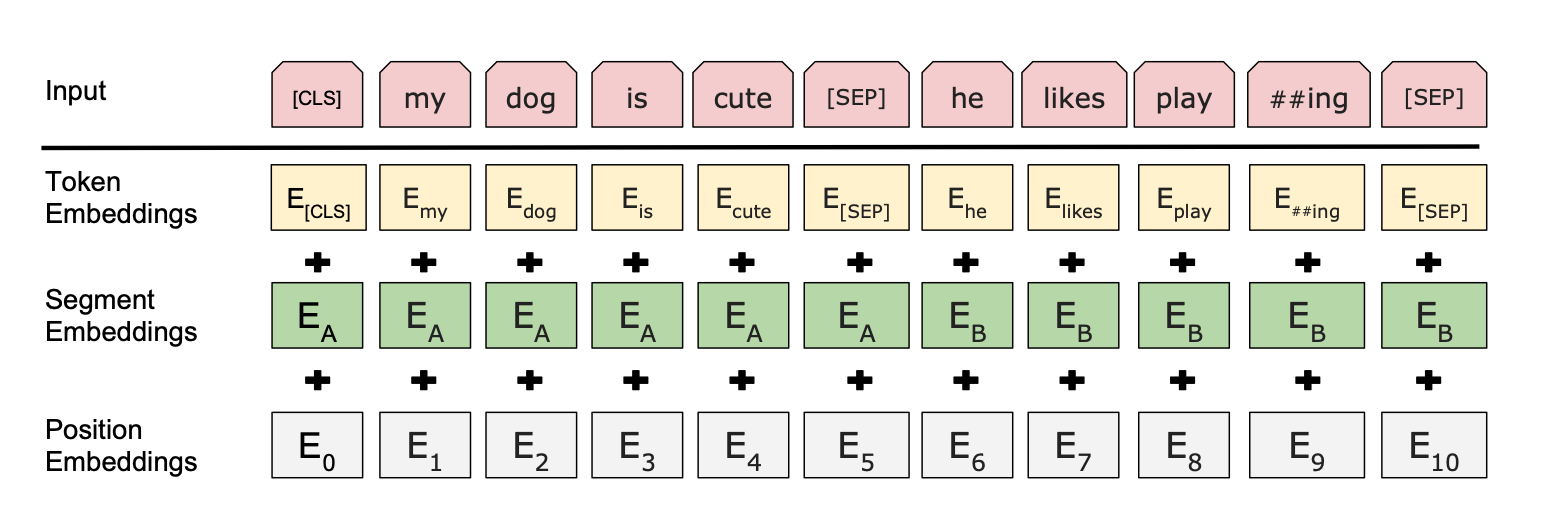

In [38]:
class Embedding(nn.Module):
  """
  Embedding层, 将三种输入信号token/segments/position 转化成嵌向量
  init
    什么参数都不需要, 只需要提前创建好下面三个超参数

  forward 使用参数 :
    1. tensor_tokens
    2. tensor_segments
    3. tensor_positions
    将三种向量转化成嵌向量, 合并后进行层归一化

  超参数:
    max_len 输入序列的最大长度, 也是函数中的seq_len
    dim_model : 神经网络, 模块和模块之间的接壤的维度
    vobal_size : 词汇表大小
  """
  def __init__(self):
    super(Embedding, self).__init__()
    self.token_embedding = nn.Embedding(vobal_size, dim_model)
    self.position_embedding = nn.Embedding(max_len, dim_model)
    self.segment_embedding = nn.Embedding(2, dim_model)
    self.norm = nn.LayerNorm(dim_model)

  def forward(self, tensor_tokens, tensor_segments, tensor_positions):

    # 三个输入向量的长度应该是一样大的 为 (batch_size, seq_len/max_len )
    assert tensor_tokens.shape == tensor_segments.shape == tensor_positions.shape, \
       f"Shapes not equal: tokens={tensor_tokens.shape}, segments={tensor_segments.shape}, positions={tensor_positions.shape}"

    seq_len = tensor_tokens.shape[1]
    embedding = self.token_embedding(tensor_tokens) + self.segment_embedding(tensor_segments) + self.position_embedding(tensor_positions)
    return self.norm(embedding)




创建一个Embedding层试一试

In [39]:
dim_model = 8
embedding = Embedding()
print(dataset.tensor_tokens.shape)
print(embedding(tensor_tokens = dataset.tensor_tokens, tensor_segments = dataset.tensor_segments, tensor_positions = dataset.tensor_positions).shape)

torch.Size([4, 30])
torch.Size([4, 30, 8])


## Encoder层

EncoderLayer 有两个主要组件, MultiHeadAttention 另外一个是FFN

### ScaledProductAttention

计算query关于Key的注意力权重attention_weights

然后乘以对应的value得到每个query token 得到一个融合所有value信息的表示向量context

In [40]:
class ScaledProductAttention(nn.Module):
  """
  输入:
  1. Query ; [batch_size, head_num, query_len, dim_query]
  2. Key ; [batch_size, head_num, key_len, dim_key]
  3. Value ; [batch_size, head_num, key_len, dim_value]
  4. attention_mask ; [batch_size, head_num, query_len, key_len]

  输出:
  scores : [batch_size, head_num, query_len, key_len] score是query关于key的注意力分数
  weights : [batch_size, head_num, query_len, key_len] weights是query关于key的注意力权重 (score 经历过softmax后的结果)
  context : [batch_size, head_num, query_len, dim_value] context是query关于value的融合
  """

  def __init__(self):
    super(ScaledProductAttention, self).__init__()

  def forward(self, query, key, value, attention_mask):
    scores = torch.matmul(query, key.transpose(-1, -2)) / math.sqrt(query.shape[-1]) # scores : [batch_size x num_heads x len_q(=len_k) x len_k(=len_q)]
    scores.masked_fill_(attention_mask, -1e9)
    weights = F.softmax(scores, dim = -1) # weights ; [batch_size, head_num, query_len, key_len]
    context = torch.matmul(weights, value) # context : [batch_size, head_num, query_len, dim_value]
    return scores, weights, context


### MultiHeadAttention

调整query, key, value的形状为多头形状, 然后丢入到单头注意力机制当中

In [41]:
class MultiHeadAttention(nn.Module):
  """
  Forward :
  1. Query : [batch_size, query_len, dim_model]
  2. Key : [batch_size, key_len, dim_model]
  3. Value : [batch_size, key_len, dim_model
  4. attention_mask [batch_size, 1/query_len, key_len] query维度如果是1, python 可以使用广播扩展, 因为mask是对key使用的

  超参数 :
  1. dim_query 是 多头当中query的模型维度
  2. dim_key 是多头当中key的模型维度, 一定要和dim_query相同
  3. dim_value 是多头当中value的模型维度, 可以和dim_query 和 dim_key不同
  4. num_heads : 使用多少个头进行计算

  备注:
  1. W_Q 将 query的特征维度 dim_model 转化成 dim_query*num_heads
  2. W_K 将 key的特征维度 dim_model 转化成 dim_key*num_heads
  3. W_V 将 value的特征维度 dim_model 转化成 dim_value*num_heads
  4. W_context_out 将 context 的特征维度 dim_value*num_heads 转化成 dim_model, 这个主要是融合注意力机制算出来的多头 context, 同时把特征维度重新转回 dim_model

  注意
  1. query和key 被分为多头后, 他们的特征维度得一样大
  2. key 和 value 的token的长度得一样大
  """
  def __init__(self):
    super(MultiHeadAttention, self).__init__()
    self.W_Q = nn.Linear(dim_model, dim_key*num_heads)
    self.W_K = nn.Linear(dim_model, dim_key*num_heads)
    self.W_V = nn.Linear(dim_model, dim_value*num_heads)
    self.context_fuse = nn.Linear(dim_value*num_heads, dim_model)
    self.LN = nn.LayerNorm(dim_model)

  def forward(self, query, key, value, attention_mask):
    # query: [batch_size x len_q x d_model], key: [batch_size x len_k x d_model], value: [batch_size x len_k x d_model]
    assert key.shape[1] == value.shape[1], f"key的长度必须和value一致, key.shape{key.shape}, value.shape{value.shape}"
    residual, batch_size = query, query.shape[0]
    # (B, S, D) -proj-> (B, S, D) -split-> (B, S, H, W) -trans-> (B, H, S, W)
    q_s = self.W_Q(query).view(batch_size, -1, num_heads, dim_key).transpose(1, 2)# q_s: [batch_size x num_heads x len_q x d_k]
    k_s = self.W_K(key).view(batch_size, -1, num_heads, dim_key).transpose(1, 2) # k_s: [batch_size x num_heads x len_k x d_k]
    v_s = self.W_V(value).view(batch_size, -1, num_heads, dim_value).transpose(1, 2) #  # v_s: [batch_size x num_heads x len_k x d_v]
    attention_mask = attention_mask.unsqueeze(1).repeat(1, num_heads, 1, 1) # attn_mask : [batch_size x num_heads x len_q x len_k]

    scores, weights, context = ScaledProductAttention()(q_s, k_s, v_s, attention_mask) # context: [batch_size x num_heads x len_q x d_v], weights/scores : [batch_size x num_heads x len_q(=len_k) x len_k(=len_q)]
    context = context.transpose(1, 2).contiguous().view(batch_size, -1, num_heads * dim_value) # context: [batch_size x len_q x num_heads * d_v]
    context_out = self.context_fuse(context)

    return self.LN(residual + context_out), weights

### FFN层

让每个网络学习到token独立学校到的消息


In [42]:
class PositionwiseFeedForward(nn.Module):
    """
    FFN网络是对每个token独立进行Linear层,用于每个token消化刚刚学习到的信息


    超参数:
    dim_model 是 模型的特征维度大小
    dim_ff 是 FFN网络中间层的特征维度大小
    """

    def __init__(self, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(dim_model, dim_ff)
        self.w_2 = nn.Linear(dim_ff, dim_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

### EncoderLayer

In [43]:
class EncoderLayer(nn.Module):
  """
  超参数 :
  1. dim_ff : FFN网络的隐藏层大小
  2. num_heads : 多头网络分头的数量
  3. dim_keyey : 是query 和 key分头后的隐藏层大小
  4. dim_valuealue : 是value分头后的隐藏层大小

  """
  def __init__(self):
       super(EncoderLayer, self).__init__()
       self.enc_self_attn = MultiHeadAttention()
       self.pos_ffn = PositionwiseFeedForward()

  def forward(self, enc_inputs, enc_self_attn_mask):
       enc_outputs, attn = self.enc_self_attn(enc_inputs, enc_inputs, enc_inputs, enc_self_attn_mask) # enc_inputs to same Q,K,V
       enc_outputs = self.pos_ffn(enc_outputs) # enc_outputs: [batch_size x len_q x d_model]
       return enc_outputs, attn

### 测试下Encoder层

In [44]:
embedding_layer = Embedding()
embedding_inputs = embedding_layer(batch_data.tensor_tokens, batch_data.tensor_segments, batch_data.tensor_positions)
scores, weights, context= ScaledProductAttention()(embedding_inputs, embedding_inputs, embedding_inputs, batch_data.tensor_pad_attention_mask)

print('Scores: ', scores[0][0],'nnAttention Scores after softmax: ', weights[0][0])

Scores:  tensor([ 2.8284e+00,  2.0894e+00,  5.6673e-01,  6.1432e-01,  7.7310e-01,
        -2.3128e-01, -8.5260e-01, -1.3565e+00, -1.5464e-01, -1.5279e-01,
        -4.8623e-01, -1.8846e+00, -1.5307e+00, -1.8897e+00, -7.8165e-01,
        -1.0000e+09, -1.0000e+09, -1.0000e+09, -1.0000e+09, -1.0000e+09,
        -1.0000e+09, -1.0000e+09, -1.0000e+09, -1.0000e+09, -1.0000e+09,
        -1.0000e+09, -1.0000e+09, -1.0000e+09, -1.0000e+09, -1.0000e+09],
       grad_fn=<SelectBackward0>) nnAttention Scores after softmax:  tensor([0.4758, 0.2272, 0.0496, 0.0520, 0.0609, 0.0223, 0.0120, 0.0072, 0.0241,
        0.0241, 0.0173, 0.0043, 0.0061, 0.0042, 0.0129, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000], grad_fn=<SelectBackward0>)


## Decoder层

### NSP_Decoder

NSP_Decoder 主要是把Encoder加工的信息进行解码, 然后进行分类任务判断是否是连续的一句话


In [45]:
class NSP_Decoder(nn.Module):
  """
  init : 无输入

  forward:
  输入 : encoder_outputs, shape是[batch_size, seq_len, dim_model]
  输出 : logits_nsp, 其shape是[batch_size, 2]


  超参数 :
  dim_model
  """
  def __init__(self):
    super(NSP_Decoder, self).__init__()
    self.linear = nn.Linear(dim_model, dim_model)
    self.dropout = nn.Dropout(0.5)
    self.tanh = nn.Tanh()
    self.nsp_classifier = nn.Linear(dim_model, 2)

  def forward(self, encoder_outputs):
    # Bert当中预测是否是连续的两句话, 会取第一个token, 也就是[CLS]位置编码后的信息作为判断, Bert认为这个位置会包含整个序列的综合信息, 因此用它作为分类的依据
    h = encoder_outputs[:, 0, :]
    logits_nsp = self.nsp_classifier(self.tanh(self.dropout(self.linear(h)))) # logits_nsp.shape = [batch_size, 2]
    return logits_nsp

### MLM_Decoder

Masked Language Model任务

其过程主要是对encoder编码后的信息, 然后取出被masked位置的向量, 然后丢入到Decoder当中

In [46]:
def gelu(x):
  "mlm_Decoder当中的激活函数是gelu"
  return x * 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))

In [47]:
class MLM_Decoder(nn.Module):
  """
  init:
  输入 :
  1. embedding: 需要使用到Embedding类中的token_embedding层的权重参数

  forward:
    输入:
    1. encoder_ouputs : encoder加工后的结果
    2. batch.tensor_masked_pos : 记录了被masked的位置信息, 用于取出对应的向量

    输出:
    1. logits_mlm : shape是[batch_size, max_pred, vobal_size] 主要是对于每一个被maksed的位置都有一个分类

  超参数
  1. dim_model
  2. vobal_size
  """
  def __init__(self, embedding):
    super(MLM_Decoder, self).__init__()
    self.linear = nn.Linear(dim_model, dim_model)
    self.gelu = gelu
    # mlm_Decoder的最后的分类器和token_Embedding层参数共享, 这里的mlm_classifier相当于让encoder_outputs和embedding层的向量做一个相似度计算,然后根据整个相似度作为分类的依据
    self.mlm_classifier = nn.Linear(dim_model, vobal_size, bias=False) # 这里不要bias, 因为embedding没有bias, 这里weight要使用embedding层的
    self.mlm_classifier.weight = embedding.token_embedding.weight # 共享token_embedding层的权重
    # self.mlm_classifier_bias = nn.Parameter(torch.zeros(vobal_size)) # 使用自己的bias

  def forward(self, encoder_outputs, tensor_masked_pos):
    """
    根据被masked的位置, 然后取出对应的encoder信息上的向量, 然后根绝这个向量进行分类
    """
    matrix_3D_masked_pos = tensor_masked_pos.unsqueeze(-1).expand(-1, -1, encoder_outputs.shape[-1]) # 这一步相当于把二维上的数字一直复制encoder_outputs.shape[-1]个, 然后方便后面gather取数字
    h_masked = torch.gather(encoder_outputs, dim = 1, index = matrix_3D_masked_pos) # 这里gather沿着 dim 维度，根据 index 取值, 相当于output[i,j,k] = input[i, index[i,j,k], k]

    # 将h_masked丢入到分类器中, 进行分类
    h_masked = self.gelu(self.linear(h_masked)) # 形状始终为[batch_size, max_pred, dim_model]
    logits_mlm = self.mlm_classifier(h_masked) #[batch_size, max_pred, dim_model] --> [batch_size, max_pred, num_vobal]

    return logits_mlm


## 完整Bert结构

In [48]:
class Bert(nn.Module):
  """
  Bert神经网络的架构, 首先Embedding 再Encoder, 然后把结果放入两个Decoder中得到, 还没经过softmax的logits

  init :
    超参数 :
    1. num_layers : encoder当中encoderlayer的数量

  forward:
    输入 :
      1. batch_data : Batch类, 存储训练用的时候的数据

    输出
      1. logits_nsp : NSP_Decoder网络加工后判断两句话是否是连续的, shape为[batch_size, 2]
      2. logits_mlm : MLM_Decoder网络加工后判断每个被masked的位置的种类分类, shape 为[batch_size, max_pred, num_vobal]

  """
  def __init__(self):
    super(Bert, self).__init__()
    self.embedding = Embedding()
    self.encoder_layers = nn.ModuleList([EncoderLayer() for _ in range(num_layers)])
    self.nsp_decoder = NSP_Decoder()
    self.mlm_decoder = MLM_Decoder(self.embedding)

  def forward(self, batch_data):
    output = self.embedding(batch_data.tensor_tokens, batch_data.tensor_segments, batch_data.tensor_positions)
    for encoder_layer in self.encoder_layers :
      output, encoder_self_attention = encoder_layer(output, batch_data.tensor_pad_attention_mask)

    logits_nsp = self.nsp_decoder(output)
    logits_mlm = self.mlm_decoder(output, batch_data.tensor_masked_pos)

    return logits_nsp, logits_mlm



## 测试下Bert

In [49]:
num_layers = 2
num_heads = 2
dim_key = dim_value = 4
dim_ff = 16
model = Bert()

logits_nsp, logits_mlm = model(batch_data)
logits_nsp.shape, logits_mlm.shape, max_pred

(torch.Size([4, 2]), torch.Size([4, 5, 40]), 5)

# Loss 和 Optimizer

使用交叉熵损失函数, 可以让神经网络少一层softmax, 更加简洁

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adadelta(model.parameters(), lr=0.001)

# Trainning

In [51]:
# 超参数设置
max_pred = 5
batch_size = 6
max_len = 30
dim_model = 768
num_layers = 6
num_heads = 12
dim_key = dim_value = 64
dim_ff = 768*4

dataset = MyDataSet(word_dict=word_dict, number_dict=number_dict, sentences=sentences)
data_loader = DataLoader(dataset,batch_size,True)
model = Bert()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adadelta(model.parameters(), lr=0.001)

for epoch in range(50):
  for temp_data in data_loader:
    batch_data = Batch(*temp_data)
    logits_nsp, logits_mlm = model(batch_data)
    # logits_mlm 的原始形状是 [batch_size, max_len, vocab_size]
    # 但 nn.CrossEntropyLoss() 要求输入形状为 [batch_size, vocab_size, seq_len]，
    loss_mlm = criterion(logits_mlm.view(-1, vobal_size), batch_data.tensor_masked_token.view(-1))
    loss_mlm = (loss_mlm.float()).mean()
    loss_nsp = criterion(logits_nsp, batch_data.tensor_bool_next)
    loss = loss_mlm + loss_nsp
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  if(epoch+1) % 10 == 0:
    print("predict ", logits_mlm.max(2)[1][0])
    print("label ", batch_data.tensor_masked_token[0])
    print('Epoch:', '%04d' % (epoch + 1), 'loss =', '{:.6f}'.format(loss))

predict  tensor([32,  0,  0,  0,  0])
label  tensor([22,  0,  0,  0,  0])
Epoch: 0010 loss = 2.460280
predict  tensor([22,  0,  0,  0,  0])
label  tensor([22,  0,  0,  0,  0])
Epoch: 0020 loss = 1.755376
predict  tensor([37,  0,  0,  0,  0])
label  tensor([37,  0,  0,  0,  0])
Epoch: 0030 loss = 1.401677
predict  tensor([22,  0,  0,  0,  0])
label  tensor([22,  0,  0,  0,  0])
Epoch: 0040 loss = 1.263535
predict  tensor([ 8, 18, 37,  0,  0])
label  tensor([ 8, 18, 10,  0,  0])
Epoch: 0050 loss = 1.064821


# Prediction

In [52]:
# 取出第一个样本的各个数据
tensor_tokens, tensor_segments, tensor_masked_pos, tensor_masked_token, tensor_positions, tensor_bool_next = map(torch.tensor, dataset.batch_data[0])

# 打印下文本
print("=========文本内容=============\n", sentences, "\n=========文本内容=============\n")


# 把要预测的数据装载到batch_data当中
batch_data_prediction = Batch(
    tensor_tokens.unsqueeze(0),        # [1, max_len]
    tensor_segments.unsqueeze(0),      # [1, max_len]
    tensor_masked_pos.unsqueeze(0),    # [1, max_pred]
    tensor_masked_token.unsqueeze(0),  # [1, max_pred]
    tensor_positions.unsqueeze(0),     # [1, max_len]
    tensor_bool_next.unsqueeze(0),     # [1]
    (tensor_tokens == word_dict['[PAD]']).unsqueeze(0)  # pad_attention_mask [1, max_len]
)


logits_nsp, logits_mlm = model(batch_data_prediction)
print([number_dict[token_number.item()] for token_number in batch_data_prediction.tensor_tokens[0] if number_dict[token_number.item()] != '[PAD]'])



logits_mlm = logits_mlm.data.max(2)[1][0].data.numpy()
print('masked token number list : ',[token.item() for token in batch_data_prediction.tensor_masked_token[0]])
print('predict masked number list : ',[pos.item() for pos in logits_mlm])

logits_nsp = logits_nsp.data.max(1)[1].data.numpy()[0]

print('isNext : ', True if batch_data_prediction.tensor_bool_next[0].item()else False)
print('predict isNext : ',True if logits_nsp else False)


=========文本内容=============
 ['hello how are you i am romeo', 'hello romeo my name is juliet nice to meet you', 'nice meet you too how are you today', 'great my baseball team won the competition', 'oh congratulations juliet', 'thank you romeo', 'where are you going today', 'i am going shopping what about you', 'i am going to visit my grandmother she is not very well'] 
=========文本内容=============

['[CLS]', 'where', 'are', 'you', 'going', '[MASK]', '[SEP]', 'i', 'am', 'going', '[MASK]', 'visit', 'my', 'grandmother', 'she', 'is', '[MASK]', 'very', 'well', '[SEP]']
masked token number list :  [27, 4, 32, 0, 0]
predict masked number list :  [27, 4, 32, 0, 0]
isNext :  False
predict isNext :  True
